In [2]:
import numpy as np
import pandas as pd
data_Tg = pd.read_excel(r'copolymer_Tg_data_real.xlsx')
data_Tm = pd.read_excel(r'copolymer_Tm_data_real.xlsx')
data_gpt_Tg = pd.read_excel(r'copolymer_Tg_data_llm.xlsx')
data_gpt_Tm = pd.read_excel(r'copolymer_Tm_data_llm.xlsx')

In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
import warnings
warnings.filterwarnings('ignore')
def get_Morgan_fingerprint_frequency(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        info={}
        fp = AllChem.GetMorganFingerprintAsBitVect(mol,3,nBits=2048,bitInfo=info)
        key=[key for key in info.keys()]
        frq=[len(value) for value in info.values()]
        new_info={key: value for key, value in zip(key, frq)}
        mff=[0] * len(list(fp))
        for key, value in new_info.items():
            mff[key] = value
    except:
        mff=None
    return mff

def get_copolymer_mfp(smi1,smi2,ratio):
    ratio=0.01*ratio
    mfp1=get_Morgan_fingerprint_frequency(smi1)
    mfp2=get_Morgan_fingerprint_frequency(smi2)
    if mfp1 is not None and mfp2 is not None:
        mfp=[mfp1[i]*ratio+mfp2[i]*(1-ratio) for i in range(len(mfp1))]
    else:
        mfp=None
    return mfp

### 1. Data preprocessing

In [4]:
data_Tg['Compotision1_ratio/%'] = pd.to_numeric(data_Tg['Compotision1_ratio/%'], errors='coerce')
data_Tm['Compotision1_ratio/%'] = pd.to_numeric(data_Tm['Compotision1_ratio/%'], errors='coerce')
data_Tg['morgan_fp_with_freq']=data_Tg.apply(lambda x: get_copolymer_mfp(x['Component 1 smiles'],x['Component 2 smiles'],x['Compotision1_ratio/%']),axis=1)
data_Tm['morgan_fp_with_freq']=data_Tm.apply(lambda x: get_copolymer_mfp(x['Component 1 smiles'],x['Component 2 smiles'],x['Compotision1_ratio/%']),axis=1)
data_Tg['Tg'] = data_Tg['Tg'].astype(float)
data_Tm['Tm']=data_Tm['Tm'].astype(float)
data_Tg= data_Tg[data_Tg['Tg'].notna()]
data_Tm= data_Tm[data_Tm['Tm'].notna()]
data_Tg=data_Tg.dropna(subset=['morgan_fp_with_freq'])
data_Tm=data_Tm.dropna(subset=['morgan_fp_with_freq'])
data_Tg=data_Tg.reset_index(drop=True)
data_Tm=data_Tm.reset_index(drop=True)

[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerator
[23:45:45] DEPRECATION WARNING: please use MorganGenerat

In [5]:
data_gpt_Tg['Composition1_ratio'] = pd.to_numeric(data_gpt_Tg['Composition1_ratio'], errors='coerce')
data_gpt_Tm['Composition1_ratio'] = pd.to_numeric(data_gpt_Tm['Composition1_ratio'], errors='coerce')
data_gpt_Tg['morgan_fp_with_freq']=data_gpt_Tg.apply(lambda x: get_copolymer_mfp(x['Component_1_smiles'],x['Component_2_smiles'],x['Composition1_ratio']),axis=1)
data_gpt_Tm['morgan_fp_with_freq']=data_gpt_Tm.apply(lambda x: get_copolymer_mfp(x['Component_1_smiles'],x['Component_2_smiles'],x['Composition1_ratio']),axis=1)
data_gpt_Tg= data_gpt_Tg[data_gpt_Tg['Glass transition temperature'].notna()]
data_gpt_Tm= data_gpt_Tm[data_gpt_Tm['Melting temperature'].notna()]
data_gpt_Tg=data_gpt_Tg.dropna(subset=['morgan_fp_with_freq'])
data_gpt_Tm=data_gpt_Tm.dropna(subset=['morgan_fp_with_freq'])
data_gpt_Tg=data_gpt_Tg.reset_index(drop=True)
data_gpt_Tm=data_gpt_Tm.reset_index(drop=True)
data_gpt_Tg = data_gpt_Tg[~data_gpt_Tg['morgan_fp_with_freq'].apply(lambda x: pd.isna(x).all() or (isinstance(x, list) and all(str(i).lower() == 'nan' for i in x)))]
data_gpt_Tm = data_gpt_Tm[~data_gpt_Tm['morgan_fp_with_freq'].apply(lambda x: pd.isna(x).all() or (isinstance(x, list) and all(str(i).lower() == 'nan' for i in x)))]

[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerator
[23:45:48] DEPRECATION WARNING: please use MorganGenerat

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,mean_absolute_percentage_error
import matplotlib.pyplot as plt

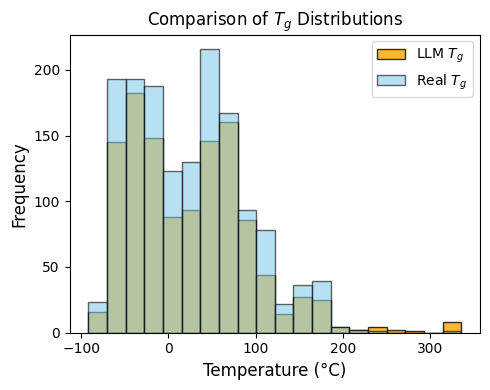

In [7]:
xmin = min(data_gpt_Tg['Glass transition temperature'].min(), data_Tg['Tg'].min())
xmax = max(data_gpt_Tg['Glass transition temperature'].max(), data_Tg['Tg'].max())
bins = np.linspace(xmin, xmax, 21)
plt.figure(figsize=(5, 4))
plt.hist(data_gpt_Tg['Glass transition temperature'], bins=bins, color='orange', edgecolor='black', alpha=0.8, label='LLM $T_{g}$')
plt.hist(data_Tg['Tg'], bins=bins, color='skyblue', edgecolor='black', alpha=0.6, label='Real $T_{g}$')
plt.title('Comparison of $T_{g}$ Distributions')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('Tg_distribution.jpg',dpi=300)

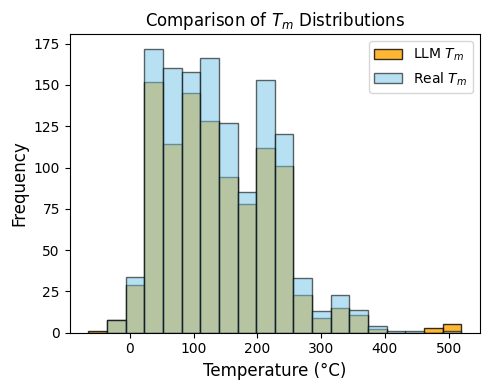

In [8]:
xmin = min(data_gpt_Tm['Melting temperature'].min(), data_Tm['Tm'].min())
xmax = max(data_gpt_Tm['Melting temperature'].max(), data_Tm['Tm'].max())
bins = np.linspace(xmin, xmax, 21)
plt.figure(figsize=(5, 4))
plt.hist(data_gpt_Tm['Melting temperature'], bins=bins, color='orange', edgecolor='black', alpha=0.8, label='LLM $T_{m}$')
plt.hist(data_Tm['Tm'], bins=bins, color='skyblue', edgecolor='black', alpha=0.6, label='Real $T_{m}$')
plt.title('Comparison of $T_{m}$ Distributions')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('Tm_distribution.jpg',dpi=300)

In [9]:
len(data_Tg), len(data_Tm)

(1509, 1273)

In [10]:
(len(data_gpt_Tg),len(data_gpt_Tm))

(1195, 1030)

In [ ]:
real_unconsisted_cols = [
    "Component 1 smiles",
    "Component 2 smiles",
    "Compotision1_ratio/%",
    "Compotision2_ratio/%"
]

duplicates = data_Tg[data_Tg.duplicated(subset=real_unconsisted_cols, keep=False)]

重复行数量：169


,ID,copolymer_name,Component_1_name,Component_2_name,Component 1 smiles,Component 2 smiles,Compotision1_ratio/%,Compotision2_ratio/%,Tg,Tm,morgan_fp_with_freq
1,1,ethylene-vinyl acetate copolymer,ethylene,vinyl acetate,*C*,*C(OC(=O)C)C*,60.0,40.0,-38.15,44.85,"[0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
25,7,poly[ethylene-co-(vinyl acetate)],ethylene,vinyl acetate,*C*,*C(OC(=O)C)C*,60.0,40.0,-17.00,62,"[0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
34,11,PET-co-10I,poly(ethylene terephthalate),poly-(ethylene isophthalate),*CCOC(=O)c1ccc(cc1)C(=O)O*,*CCOC(=O)c1cccc(c1)C(=O)O*,90.0,10.0,72.00,233,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
35,11,PET-co-20I,poly(ethylene terephthalate),poly-(ethylene isophthalate),*CCOC(=O)c1ccc(cc1)C(=O)O*,*CCOC(=O)c1cccc(c1)C(=O)O*,80.0,20.0,68.00,205,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
36,11,PET-co-30I,poly(ethylene terephthalate),poly-(ethylene isophthalate),*CCOC(=O)c1ccc(cc1)C(=O)O*,*CCOC(=O)c1cccc(c1)C(=O)O*,70.0,30.0,66.00,Nan,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
1460,372,NaN,Methyl methacrylate (MMA),"3,5-bis[2-(N-ethylanilino)ethoxy]benzyl methac...",*C(C(=O)OC)(C*)C,CCN(CCOc1cc(COC(=O)C(C)(*)C*)cc(OCCN(CC)c2cccc...,97.0,3.0,96.00,Nan,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1464,372,NaN,Methyl methacrylate (MMA),"3,5-bis[2-(N-ethylanilino)ethoxy]benzyl methac...",*C(C(=O)OC)(C*)C,CCN(CCOc1cc(COC(=O)C(C)(*)C*)cc(OCCN(CC)c2cccc...,97.0,3.0,104.00,Nan,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1469,373,NaN,L-Lactide (LA),ε-Caprolactone (CL),*OC(C(=O)*)C,*CCCCCC(=O)O*,67.0,33.0,15.87,Nan,"[0.0, 0.67, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1490,384,NaN,Vinyl alcohol,Ethylene,*CC(O)*,*C*,73.0,27.0,70.00,197,"[0.0, 0.73, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [ ]:
import numpy as np
import pandas as pd

real_unconsisted_cols = [
    "Component 1 smiles",
    "Component 2 smiles",
    "Compotision1_ratio/%",
    "Compotision2_ratio/%"
]

Tg_col = "Tg"

def clean(series, z_thres=3):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan

    if len(s) <= 2:
        return s.mean()

    std = s.std(ddof=0)
    if std == 0:
        return s.mean()

    z = (s - s.mean()) / std
    s_filtered = s[abs(z) <= z_thres]

    if len(s_filtered) == 0:
        s_filtered = s

    return s_filtered.mean()

data_Tg_clean = (
    data_Tg
    .groupby(real_unconsisted_cols, as_index=False)
    .agg({Tg_col: lambda s: clean(s, z_thres=3)})
)

Tm_col = "Tm"

data_Tm_clean = (
    data_Tm
    .groupby(real_unconsisted_cols, as_index=False)
    .agg({Tm_col: lambda s: clean(s, z_thres=3)})
)

gpt_unconsisted_cols = [
    "Component_1_smiles",
    "Component_2_smiles",
    "Composition1_ratio",
    "Composition2_ratio"
]
gpt_Tg_col = "Glass transition temperature"
gpt_Tm_col = "Melting temperature"

data_gpt_Tg_clean = (
    data_gpt_Tg
    .groupby(gpt_unconsisted_cols, as_index=False)
    .agg({gpt_Tg_col: lambda s: clean(s, z_thres=3)})
)

data_gpt_Tm_clean = (
    data_gpt_Tm
    .groupby(gpt_unconsisted_cols, as_index=False)
    .agg({gpt_Tm_col: lambda s: clean(s, z_thres=3)})
)

In [15]:
data_Tg_clean['morgan_fp_with_freq']=data_Tg_clean.apply(lambda x: get_copolymer_mfp(x['Component 1 smiles'],x['Component 2 smiles'],x['Compotision1_ratio/%']),axis=1)
data_Tm_clean['morgan_fp_with_freq']=data_Tm_clean.apply(lambda x: get_copolymer_mfp(x['Component 1 smiles'],x['Component 2 smiles'],x['Compotision1_ratio/%']),axis=1)
data_gpt_Tg_clean['morgan_fp_with_freq']=data_gpt_Tg_clean.apply(lambda x: get_copolymer_mfp(x['Component_1_smiles'],x['Component_2_smiles'],x['Composition1_ratio']),axis=1)
data_gpt_Tm_clean['morgan_fp_with_freq']=data_gpt_Tm_clean.apply(lambda x: get_copolymer_mfp(x['Component_1_smiles'],x['Component_2_smiles'],x['Composition1_ratio']),axis=1)

[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerator
[23:45:53] DEPRECATION WARNING: please use MorganGenerat

In [16]:
print(len(data_Tg_clean), len(data_Tm_clean))
print(len(data_gpt_Tg_clean),len(data_gpt_Tm_clean))

1411 1190
1124 969


## 2. QSPR for $T_g$

### 2.1 Real $T_g$ prediction performance

#### 2.1.1 RF

In [ ]:
### find best RF param
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_r2 = -np.inf
best_params = None
best_results = {}

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]
}


from itertools import product
param_combinations = list(product(param_grid['n_estimators'], param_grid['max_depth'],
                                   param_grid['min_samples_split'], param_grid['min_samples_leaf']))

X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()
X = np.array(X_Tg_real)
y = np.array(y_Tg_real)

kf = KFold(n_splits=10, shuffle=True, random_state=30)

for n_est, max_d, min_split, min_leaf in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_full, y_train_full,
            test_size=1/9,          
            random_state=42
        )
        
        model = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)
        
        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)
    
    mean_r2_valid = np.mean(r2_valid_scores)
    print(f"Params: n_estimators={n_est}, max_depth={max_d}, min_samples_split={min_split}, min_samples_leaf={min_leaf} => mean R2: {mean_r2_valid:.4f}")
    
    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_params = (n_est, max_d, min_split, min_leaf)
        best_results = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'n_estimators': n_est,
                'max_depth': max_d,
                'min_samples_split': min_split,
                'min_samples_leaf': min_leaf
            }
        }

print("\n✅ Best Parameters and R2 Score:")
print(best_results)


Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1 => mean R2: 0.8859
Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=2 => mean R2: 0.8802
Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=3 => mean R2: 0.8734
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=1 => mean R2: 0.8849
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=2 => mean R2: 0.8802
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=3 => mean R2: 0.8734
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=1 => mean R2: 0.8848
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=2 => mean R2: 0.8802
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=3 => mean R2: 0.8734
Params: n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1 => mean R2:

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()


if not os.path.exists('251122_Real_Tg_RF_10fold_saved_models'):
    os.makedirs('251122_Real_Tg_RF_10fold_saved_models')

X = np.array(X_Tg_real)
y = np.array(y_Tg_real)

kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,           
        random_state=42
    )

    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    
    model_filename = f'251122_Real_Tg_RF_10fold_saved_models/RF_{i+1:03d}.pkl'
    joblib.dump(model, model_filename)
    print(f'Model saved as {model_filename}')

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_001.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_002.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_003.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_004.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_005.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_006.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_007.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_008.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_009.pkl
Model saved as 251122_Real_Tg_RF_10fold_saved_models/RF_010.pkl


In [18]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 50.6466 ± 3.7462, MAE: 4.0046 ± 0.0772, R2: 0.9876 ± 0.0009
Mean Validation MSE: 507.6041 ± 174.3490, MAE: 11.1008 ± 1.1824, R2: 0.8868 ± 0.0328
Mean Test MSE: 355.7895 ± 108.4127, MAE: 10.4349 ± 0.8571, R2: 0.9136 ± 0.0220


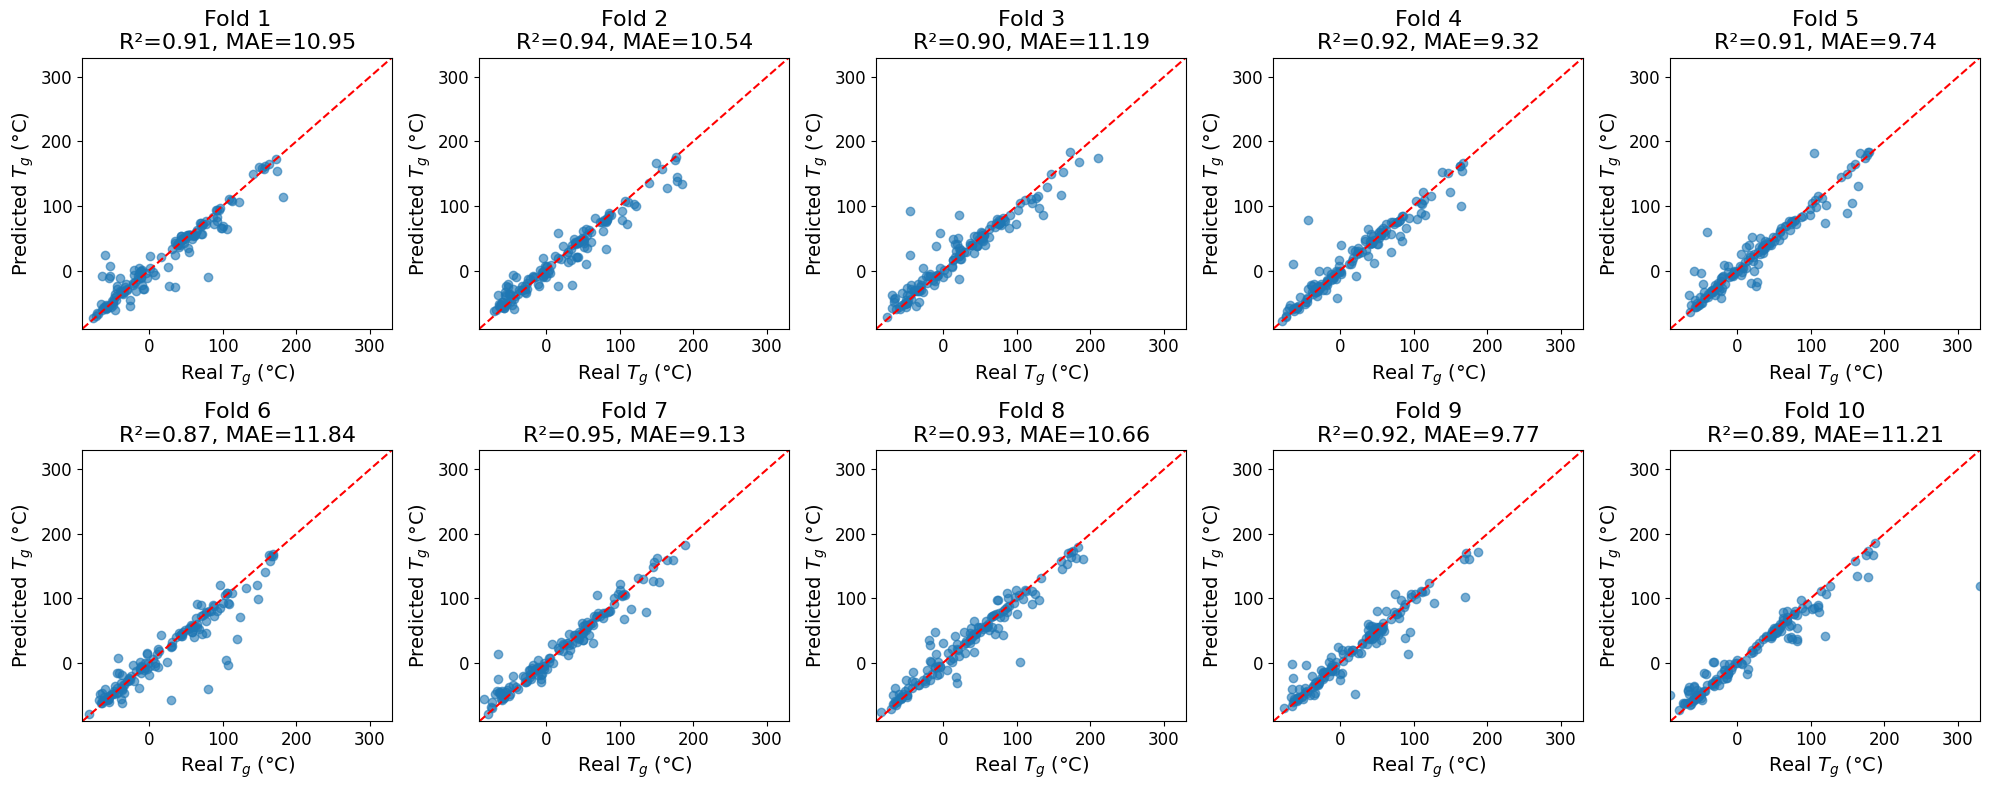

In [ ]:
#### Real vs Predicted Tg for Each Fold (Test Set)
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
import matplotlib.pyplot as plt


X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()


X = np.array(X_Tg_real)
y = np.array(y_Tg_real)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []


test_true_list = []
test_pred_list = []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

   
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))

    test_true_list.append(y_test)
    test_pred_list.append(test_preds)


fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

all_true = np.concatenate(test_true_list)
all_pred = np.concatenate(test_pred_list)
min_val = min(all_true.min(), all_pred.min())
max_val = max(all_true.max(), all_pred.max())

for i in range(10):
    ax = axes[i]
    ax.scatter(test_true_list[i], test_pred_list[i], alpha=0.6)


    ax.plot(
        [min_val, max_val], [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=1.5
    )
    
    r2 = r2_test_scores[i]
    mae = mae_test_scores[i]
    ax.set_title(f'Fold {i+1}\nR²={r2:.2f}, MAE={mae:.2f}', fontsize=16)

    ax.set_xlabel('Real $T_{g}$ (°C)', fontsize=14)
    ax.set_ylabel('Predicted $T_{g}$ (°C)', fontsize=14)
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('251211_real_Tg_10_cv.jpg', dpi=400)



#### 2.1.2 Xgboost

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()

X = np.array(X_Tg_real)
y = np.array(y_Tg_real)

param_grid = {
    'n_estimators': [100,150,200],        
    'max_depth': [None, 10, 20],            
    'learning_rate': [0.05, 0.1],      
    'subsample': [0.8, 1.0],           
    'colsample_bytree': [0.8, 1.0]      
}

param_combinations = list(product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['subsample'],
    param_grid['colsample_bytree']
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2 = -np.inf
best_results = {}

for (n_est, max_d, lr, subsample, colsample) in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=1/9, random_state=42
        )

        model = XGBRegressor(
            n_estimators=n_est,
            max_depth=max_d,
            learning_rate=lr,
            subsample=subsample,
            colsample_bytree=colsample,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            tree_method='hist'  
        )

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: n_estimators={n_est}, max_depth={max_d}, "
        f"learning_rate={lr}, subsample={subsample}, "
        f"colsample_bytree={colsample} "
        f"=> mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_results = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'n_estimators': n_est,
                'max_depth': max_d,
                'learning_rate': lr,
                'subsample': subsample,
                'colsample_bytree': colsample
            }
        }

print("\n✅ Best Parameters and R2 Score (XGBoost):")
print(best_results)

Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8 => mean R2: 0.8759
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=0.8, colsample_bytree=1.0 => mean R2: 0.8727
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=1.0, colsample_bytree=0.8 => mean R2: 0.8727
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0 => mean R2: 0.8710
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8 => mean R2: 0.8838
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=0.8, colsample_bytree=1.0 => mean R2: 0.8820
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0, colsample_bytree=0.8 => mean R2: 0.8873
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0 => mean R2: 0.8828
Params: n_estimators=100, max_depth=10, learning_rate=0.05, subsampl

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()


X = np.array(X_Tg_real)
y = np.array(y_Tg_real)

kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

   
    model =  XGBRegressor(
        n_estimators=200,
        max_depth=None,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'  
    )
    
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [76]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 23.5296 ± 1.2914, MAE: 3.3750 ± 0.0939, R2: 0.9942 ± 0.0003
Mean Validation MSE: 483.3910 ± 166.7898, MAE: 10.7288 ± 1.0607, R2: 0.8914 ± 0.0349
Mean Test MSE: 374.4125 ± 203.7317, MAE: 10.2997 ± 1.4295, R2: 0.9109 ± 0.0387


#### 2.1.3 SVM

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()
X = np.array(X_Tg_real)
y = np.array(y_Tg_real)

param_grid = {
    'C': [1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2],
    'gamma': [0.01, 0.05, 0.1]
}

param_combinations = list(product(
    param_grid['C'],
    param_grid['epsilon'],
    param_grid['gamma']
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2 = -np.inf
best_results_svm = {}

for C, eps, gamma in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=1/9, random_state=42
        )

        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                C=C,
                epsilon=eps,
                gamma=gamma,
                kernel='rbf'
            ))
        ])

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: C={C}, epsilon={eps}, gamma={gamma} "
        f"=> mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_results_svm = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'C': C,
                'epsilon': eps,
                'gamma': gamma,
                'kernel': 'rbf'
            }
        }

print("\n✅ Best Parameters and R2 Score (SVR):")
print(best_results_svm)


Params: C=1, epsilon=0.01, gamma=0.01 => mean R2: 0.1792
Params: C=1, epsilon=0.01, gamma=0.05 => mean R2: 0.0837
Params: C=1, epsilon=0.01, gamma=0.1 => mean R2: 0.0635
Params: C=1, epsilon=0.05, gamma=0.01 => mean R2: 0.1793
Params: C=1, epsilon=0.05, gamma=0.05 => mean R2: 0.0837
Params: C=1, epsilon=0.05, gamma=0.1 => mean R2: 0.0635
Params: C=1, epsilon=0.1, gamma=0.01 => mean R2: 0.1793
Params: C=1, epsilon=0.1, gamma=0.05 => mean R2: 0.0837
Params: C=1, epsilon=0.1, gamma=0.1 => mean R2: 0.0635
Params: C=1, epsilon=0.2, gamma=0.01 => mean R2: 0.1793
Params: C=1, epsilon=0.2, gamma=0.05 => mean R2: 0.0837
Params: C=1, epsilon=0.2, gamma=0.1 => mean R2: 0.0634
Params: C=10, epsilon=0.01, gamma=0.01 => mean R2: 0.4357
Params: C=10, epsilon=0.01, gamma=0.05 => mean R2: 0.2920
Params: C=10, epsilon=0.01, gamma=0.1 => mean R2: 0.2356
Params: C=10, epsilon=0.05, gamma=0.01 => mean R2: 0.4356
Params: C=10, epsilon=0.05, gamma=0.05 => mean R2: 0.2920
Params: C=10, epsilon=0.05, gamma=0.1

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()


X = np.array(X_Tg_real)
y = np.array(y_Tg_real)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]


    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )


    model =  Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                C=100,
                epsilon=0.01,
                gamma=0.01,
                kernel='rbf'
            ))
        ])
    
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

   
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [78]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 113.0698 ± 24.3910, MAE: 3.4014 ± 0.1976, R2: 0.9722 ± 0.0059
Mean Validation MSE: 1352.6966 ± 304.8079, MAE: 19.6673 ± 1.4763, R2: 0.6963 ± 0.0404
Mean Test MSE: 1276.8015 ± 337.5225, MAE: 20.9156 ± 2.4714, R2: 0.6895 ± 0.0661


#### 2.1.4 MLP

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()
X = np.array(X_Tg_real)
y = np.array(y_Tg_real)

param_grid_mlp = {
    'hidden_layer_sizes': [(64, 64), (128, 64), (128, 128)],
    'alpha': [1e-4, 1e-3, 1e-2],            
    'learning_rate_init': [1e-3, 5e-3],     
}

param_combinations_mlp = list(product(
    param_grid_mlp['hidden_layer_sizes'],
    param_grid_mlp['alpha'],
    param_grid_mlp['learning_rate_init'],
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2_mlp = -np.inf
best_results_mlp = {}

for hls, alpha, lr_init in param_combinations_mlp:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=0.111, random_state=42
        )

    
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=hls,
                alpha=alpha,
                learning_rate_init=lr_init,
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=42,
                early_stopping=True,       
                n_iter_no_change=20,
                verbose=False
            ))
        ])

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: hidden_layer_sizes={hls}, alpha={alpha}, "
        f"learning_rate_init={lr_init} => mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2_mlp:
        best_r2_mlp = mean_r2_valid
        best_results_mlp = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'hidden_layer_sizes': hls,
                'alpha': alpha,
                'learning_rate_init': lr_init,
                'activation': 'relu',
                'solver': 'adam',
            }
        }

print("\n✅ Best Parameters and R2 Score (MLP):")
print(best_results_mlp)


Params: hidden_layer_sizes=(64, 64), alpha=0.0001, learning_rate_init=0.001 => mean R2: 0.3706
Params: hidden_layer_sizes=(64, 64), alpha=0.0001, learning_rate_init=0.005 => mean R2: -0.2516
Params: hidden_layer_sizes=(64, 64), alpha=0.001, learning_rate_init=0.001 => mean R2: 0.3681
Params: hidden_layer_sizes=(64, 64), alpha=0.001, learning_rate_init=0.005 => mean R2: -0.0164
Params: hidden_layer_sizes=(64, 64), alpha=0.01, learning_rate_init=0.001 => mean R2: 0.3701
Params: hidden_layer_sizes=(64, 64), alpha=0.01, learning_rate_init=0.005 => mean R2: 0.1767
Params: hidden_layer_sizes=(128, 64), alpha=0.0001, learning_rate_init=0.001 => mean R2: 0.7090
Params: hidden_layer_sizes=(128, 64), alpha=0.0001, learning_rate_init=0.005 => mean R2: 0.7438
Params: hidden_layer_sizes=(128, 64), alpha=0.001, learning_rate_init=0.001 => mean R2: 0.6886
Params: hidden_layer_sizes=(128, 64), alpha=0.001, learning_rate_init=0.005 => mean R2: 0.7600
Params: hidden_layer_sizes=(128, 64), alpha=0.01, le

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

X_Tg_real = data_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_real = data_Tg_clean['Tg'].tolist()


X = np.array(X_Tg_real)
y = np.array(y_Tg_real)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]


    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,           
        random_state=42
    )


    model =  Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=(128, 64),
                alpha=0.001,
                learning_rate_init=0.005,
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=42,
                early_stopping=True,       
                n_iter_no_change=20,
                verbose=False
            ))
        ])
    
    model.fit(X_train, y_train)


    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)


    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [80]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 190.7240 ± 61.9358, MAE: 7.4933 ± 1.0841, R2: 0.9531 ± 0.0153
Mean Validation MSE: 1013.1298 ± 577.1655, MAE: 13.5727 ± 2.5339, R2: 0.7781 ± 0.1172
Mean Test MSE: 884.8528 ± 1029.3425, MAE: 12.7280 ± 2.4508, R2: 0.7929 ± 0.2261


### 2.2 LLM $T_g$ prediction performance

#### 2.2.1 RF

In [ ]:
### find best RF param
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_r2 = -np.inf
best_params = None
best_results = {}

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]
}


from itertools import product
param_combinations = list(product(param_grid['n_estimators'], param_grid['max_depth'],
                                   param_grid['min_samples_split'], param_grid['min_samples_leaf']))

X_Tg_gpt = data_gpt_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_gpt = data_gpt_Tg_clean['Glass transition temperature'].tolist()
X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)

kf = KFold(n_splits=10, shuffle=True, random_state=30)

for n_est, max_d, min_split, min_leaf in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_full, y_train_full,
            test_size=1/9,          
            random_state=42
        )
        
        model = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)
        
        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)
    
    mean_r2_valid = np.mean(r2_valid_scores)
    print(f"Params: n_estimators={n_est}, max_depth={max_d}, min_samples_split={min_split}, min_samples_leaf={min_leaf} => mean R2: {mean_r2_valid:.4f}")
    
    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_params = (n_est, max_d, min_split, min_leaf)
        best_results = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'n_estimators': n_est,
                'max_depth': max_d,
                'min_samples_split': min_split,
                'min_samples_leaf': min_leaf
            }
        }

print("\n✅ Best Parameters and R2 Score:")
print(best_results)


Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1 => mean R2: 0.7354
Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=2 => mean R2: 0.7438
Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=3 => mean R2: 0.7533
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=1 => mean R2: 0.7346
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=2 => mean R2: 0.7438
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=3 => mean R2: 0.7533
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=1 => mean R2: 0.7360
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=2 => mean R2: 0.7438
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=3 => mean R2: 0.7533
Params: n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1 => mean R2:

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

X_Tg_gpt = data_gpt_Tg_clean['morgan_fp_with_freq'].tolist()
y_Tg_gpt = data_gpt_Tg_clean['Glass transition temperature'].tolist()


X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

   
    model = RandomForestRegressor(
        n_estimators=150,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [22]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 444.6088 ± 36.6054, MAE: 9.4536 ± 0.2991, R2: 0.9052 ± 0.0075
Mean Validation MSE: 1099.4787 ± 416.0477, MAE: 17.0677 ± 1.4370, R2: 0.7536 ± 0.1035
Mean Test MSE: 1024.8501 ± 461.9019, MAE: 16.0694 ± 2.4632, R2: 0.7855 ± 0.0717


#### 2.2.2 Xgboost

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)

param_grid = {
    'n_estimators': [100,150,200],        
    'max_depth': [None, 10, 20],            
    'learning_rate': [0.05, 0.1],      
    'subsample': [0.8, 1.0],           
    'colsample_bytree': [0.8, 1.0]      
}

param_combinations = list(product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['subsample'],
    param_grid['colsample_bytree']
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2 = -np.inf
best_results = {}

for (n_est, max_d, lr, subsample, colsample) in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

    
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=1/9, random_state=42
        )

        model = XGBRegressor(
            n_estimators=n_est,
            max_depth=max_d,
            learning_rate=lr,
            subsample=subsample,
            colsample_bytree=colsample,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            tree_method='hist' 
        )

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: n_estimators={n_est}, max_depth={max_d}, "
        f"learning_rate={lr}, subsample={subsample}, "
        f"colsample_bytree={colsample} "
        f"=> mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_results = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'n_estimators': n_est,
                'max_depth': max_d,
                'learning_rate': lr,
                'subsample': subsample,
                'colsample_bytree': colsample
            }
        }

print("\n✅ Best Parameters and R2 Score (XGBoost):")
print(best_results)

Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8 => mean R2: 0.7274
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=0.8, colsample_bytree=1.0 => mean R2: 0.7308
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=1.0, colsample_bytree=0.8 => mean R2: 0.7412
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0 => mean R2: 0.7465
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8 => mean R2: 0.7292
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=0.8, colsample_bytree=1.0 => mean R2: 0.7323
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0, colsample_bytree=0.8 => mean R2: 0.7430
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0 => mean R2: 0.7513
Params: n_estimators=100, max_depth=10, learning_rate=0.05, subsampl

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

if not os.path.exists('251122_LLM_Tg_XGBoost_10fold_saved_models'):
    os.makedirs('251122_LLM_Tg_XGBoost_10fold_saved_models')

X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
   
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

   
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

    
    model =  XGBRegressor(
        n_estimators=100,
        max_depth=None,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'  
    )
    
    model.fit(X_train, y_train)

    model_filename = f'251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_{i+1:03d}.pkl'
    joblib.dump(model, model_filename)
    print(f'Model saved as {model_filename}')

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_001.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_002.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_003.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_004.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_005.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_006.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_007.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_008.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_009.pkl
Model saved as 251122_LLM_Tg_XGBoost_10fold_saved_models/XGB_010.pkl


In [24]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 131.2682 ± 9.6353, MAE: 7.0429 ± 0.2819, R2: 0.9720 ± 0.0021
Mean Validation MSE: 1104.6282 ± 439.1872, MAE: 16.2837 ± 2.1506, R2: 0.7513 ± 0.1120
Mean Test MSE: 996.9736 ± 475.2926, MAE: 15.3223 ± 2.4363, R2: 0.7912 ± 0.0789


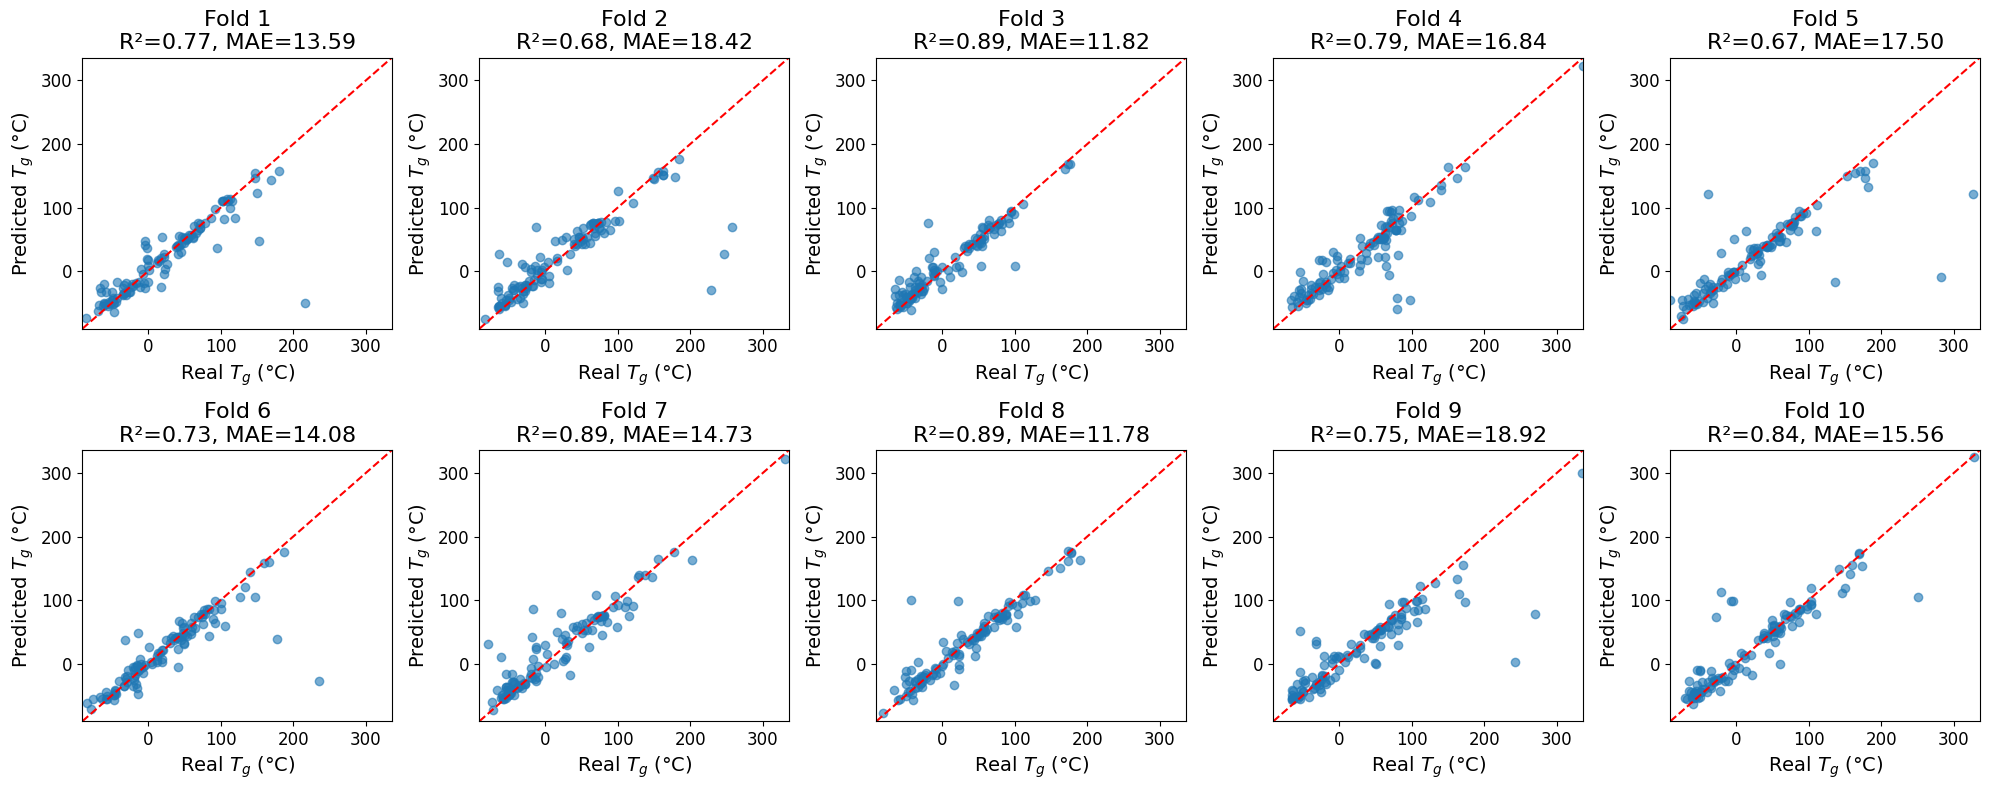

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
import matplotlib.pyplot as plt 


X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

test_true_list = []
test_pred_list = []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

   
    model =  XGBRegressor(
        n_estimators=100,
        max_depth=None,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'  
    )
    
    model.fit(X_train, y_train)


    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

   
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))


    test_true_list.append(y_test)
    test_pred_list.append(test_preds)


fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()


all_true = np.concatenate(test_true_list)
all_pred = np.concatenate(test_pred_list)
min_val = min(all_true.min(), all_pred.min())
max_val = max(all_true.max(), all_pred.max())

for i in range(10):
    ax = axes[i]
    ax.scatter(test_true_list[i], test_pred_list[i], alpha=0.6)

    
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=1.5
    )
    
    r2 = r2_test_scores[i]
    mae = mae_test_scores[i]
    ax.set_title(f'Fold {i+1}\nR²={r2:.2f}, MAE={mae:.2f}', fontsize=16)

    ax.set_xlabel('Real $T_{g}$ (°C)', fontsize=14)
    ax.set_ylabel('Predicted $T_{g}$ (°C)', fontsize=14)
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('251211_LLM_Tg_10_cv.jpg', dpi=400)



#### 2.2.3 SVM

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)

param_grid = {
    'C': [1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2],
    'gamma': [0.01, 0.05, 0.1]
}

param_combinations = list(product(
    param_grid['C'],
    param_grid['epsilon'],
    param_grid['gamma']
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2 = -np.inf
best_results_svm = {}

for C, eps, gamma in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=1/9, random_state=42
        )

        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                C=C,
                epsilon=eps,
                gamma=gamma,
                kernel='rbf'
            ))
        ])

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: C={C}, epsilon={eps}, gamma={gamma} "
        f"=> mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_results_svm = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'C': C,
                'epsilon': eps,
                'gamma': gamma,
                'kernel': 'rbf'
            }
        }

print("\n✅ Best Parameters and R2 Score (SVR):")
print(best_results_svm)


Params: C=1, epsilon=0.01, gamma=0.01 => mean R2: 0.0983
Params: C=1, epsilon=0.01, gamma=0.05 => mean R2: 0.0298
Params: C=1, epsilon=0.01, gamma=0.1 => mean R2: 0.0192
Params: C=1, epsilon=0.05, gamma=0.01 => mean R2: 0.0983
Params: C=1, epsilon=0.05, gamma=0.05 => mean R2: 0.0298
Params: C=1, epsilon=0.05, gamma=0.1 => mean R2: 0.0192
Params: C=1, epsilon=0.1, gamma=0.01 => mean R2: 0.0983
Params: C=1, epsilon=0.1, gamma=0.05 => mean R2: 0.0298
Params: C=1, epsilon=0.1, gamma=0.1 => mean R2: 0.0192
Params: C=1, epsilon=0.2, gamma=0.01 => mean R2: 0.0983
Params: C=1, epsilon=0.2, gamma=0.05 => mean R2: 0.0298
Params: C=1, epsilon=0.2, gamma=0.1 => mean R2: 0.0192
Params: C=10, epsilon=0.01, gamma=0.01 => mean R2: 0.3171
Params: C=10, epsilon=0.01, gamma=0.05 => mean R2: 0.1834
Params: C=10, epsilon=0.01, gamma=0.1 => mean R2: 0.1352
Params: C=10, epsilon=0.05, gamma=0.01 => mean R2: 0.3171
Params: C=10, epsilon=0.05, gamma=0.05 => mean R2: 0.1834
Params: C=10, epsilon=0.05, gamma=0.1

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

    
    model =  Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                C=100,
                epsilon=0.01,
                gamma=0.01,
                kernel='rbf'
            ))
        ])
    
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [89]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 704.1288 ± 84.3841, MAE: 5.3730 ± 0.3128, R2: 0.8501 ± 0.0164
Mean Validation MSE: 1894.3803 ± 331.1016, MAE: 23.8960 ± 2.4337, R2: 0.5812 ± 0.0777
Mean Test MSE: 1964.3498 ± 766.5320, MAE: 24.6557 ± 3.4446, R2: 0.5868 ± 0.1095


#### 2.2.4 MLP

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)

param_grid_mlp = {
    'hidden_layer_sizes': [(64, 64), (128, 64), (128, 128)],
    'alpha': [1e-4, 1e-3, 1e-2],            
    'learning_rate_init': [1e-3, 5e-3],     
}

param_combinations_mlp = list(product(
    param_grid_mlp['hidden_layer_sizes'],
    param_grid_mlp['alpha'],
    param_grid_mlp['learning_rate_init'],
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2_mlp = -np.inf
best_results_mlp = {}

for hls, alpha, lr_init in param_combinations_mlp:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=0.111, random_state=42
        )

        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=hls,
                alpha=alpha,
                learning_rate_init=lr_init,
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=42,
                early_stopping=True,       
                n_iter_no_change=20,
                verbose=False
            ))
        ])

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: hidden_layer_sizes={hls}, alpha={alpha}, "
        f"learning_rate_init={lr_init} => mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2_mlp:
        best_r2_mlp = mean_r2_valid
        best_results_mlp = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'hidden_layer_sizes': hls,
                'alpha': alpha,
                'learning_rate_init': lr_init,
                'activation': 'relu',
                'solver': 'adam',
            }
        }

print("\n✅ Best Parameters and R2 Score (MLP):")
print(best_results_mlp)


Params: hidden_layer_sizes=(64, 64), alpha=0.0001, learning_rate_init=0.001 => mean R2: 0.6072
Params: hidden_layer_sizes=(64, 64), alpha=0.0001, learning_rate_init=0.005 => mean R2: 0.4817
Params: hidden_layer_sizes=(64, 64), alpha=0.001, learning_rate_init=0.001 => mean R2: 0.6086
Params: hidden_layer_sizes=(64, 64), alpha=0.001, learning_rate_init=0.005 => mean R2: 0.4868
Params: hidden_layer_sizes=(64, 64), alpha=0.01, learning_rate_init=0.001 => mean R2: 0.6078
Params: hidden_layer_sizes=(64, 64), alpha=0.01, learning_rate_init=0.005 => mean R2: 0.4830
Params: hidden_layer_sizes=(128, 64), alpha=0.0001, learning_rate_init=0.001 => mean R2: 0.5507
Params: hidden_layer_sizes=(128, 64), alpha=0.0001, learning_rate_init=0.005 => mean R2: 0.5049
Params: hidden_layer_sizes=(128, 64), alpha=0.001, learning_rate_init=0.001 => mean R2: 0.5512
Params: hidden_layer_sizes=(128, 64), alpha=0.001, learning_rate_init=0.005 => mean R2: 0.5126
Params: hidden_layer_sizes=(128, 64), alpha=0.01, lear

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

X = np.array(X_Tg_gpt)
y = np.array(y_Tg_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

    
    model =  Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=(64, 64),
                alpha=0.001,
                learning_rate_init=0.001,
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=42,
                early_stopping=True,      
                n_iter_no_change=20,
                verbose=False
            ))
        ])
    
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [93]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 854.1812 ± 124.5194, MAE: 12.6656 ± 1.7085, R2: 0.8179 ± 0.0274
Mean Validation MSE: 1761.9651 ± 971.1073, MAE: 19.7404 ± 3.5799, R2: 0.6086 ± 0.2238
Mean Test MSE: 1373.0059 ± 511.4061, MAE: 18.6733 ± 3.1339, R2: 0.7061 ± 0.0868


## 3. QSPR $T_m$ Prediction

### 3.1 Real $T_m$ Prediction performance

#### 3.1.1 RF

In [91]:
### find best RF param
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_Tm_real = data_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_real = data_Tm_clean['Tm'].tolist()

best_r2 = -np.inf
best_params = None
best_results = {}

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]
}


from itertools import product
param_combinations = list(product(param_grid['n_estimators'], param_grid['max_depth'],
                                   param_grid['min_samples_split'], param_grid['min_samples_leaf']))

X = np.array(X_Tm_real)
y = np.array(y_Tm_real)
kf = KFold(n_splits=10, shuffle=True, random_state=30)

for n_est, max_d, min_split, min_leaf in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_full, y_train_full,
            test_size=1/9,          
            random_state=42
        )
        
        model = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)
        
        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)
    
    mean_r2_valid = np.mean(r2_valid_scores)
    print(f"Params: n_estimators={n_est}, max_depth={max_d}, min_samples_split={min_split}, min_samples_leaf={min_leaf} => mean R2: {mean_r2_valid:.4f}")
    
    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_params = (n_est, max_d, min_split, min_leaf)
        best_results = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'n_estimators': n_est,
                'max_depth': max_d,
                'min_samples_split': min_split,
                'min_samples_leaf': min_leaf
            }
        }

print("\n✅ Best Parameters and R2 Score:")
print(best_results)


Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1 => mean R2: 0.8594
Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=2 => mean R2: 0.8517
Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=3 => mean R2: 0.8407
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=1 => mean R2: 0.8594
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=2 => mean R2: 0.8517
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=3 => mean R2: 0.8407
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=1 => mean R2: 0.8579
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=2 => mean R2: 0.8517
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=3 => mean R2: 0.8407
Params: n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1 => mean R2:

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

X_Tm_real = data_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_real = data_Tm_clean['Tm'].tolist()


X = np.array(X_Tm_real)
y = np.array(y_Tm_real)

kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

    
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [28]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 164.7574 ± 11.4550, MAE: 6.9971 ± 0.1328, R2: 0.9767 ± 0.0015
Mean Validation MSE: 1003.6309 ± 329.8638, MAE: 16.9490 ± 1.9518, R2: 0.8594 ± 0.0405
Mean Test MSE: 1036.3968 ± 432.4626, MAE: 17.8651 ± 1.9054, R2: 0.8544 ± 0.0484


#### 3.1.2 Xgboost

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


X = np.array(X_Tm_real)
y = np.array(y_Tm_real)

param_grid = {
    'n_estimators': [100,150,200],        
    'max_depth': [None, 10, 20],            
    'learning_rate': [0.05, 0.1],      
    'subsample': [0.8, 1.0],           
    'colsample_bytree': [0.8, 1.0]      
}

param_combinations = list(product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['subsample'],
    param_grid['colsample_bytree']
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2 = -np.inf
best_results = {}

for (n_est, max_d, lr, subsample, colsample) in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        # 再从训练集中划分一部分做 valid
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=1/9, random_state=42
        )

        model = XGBRegressor(
            n_estimators=n_est,
            max_depth=max_d,
            learning_rate=lr,
            subsample=subsample,
            colsample_bytree=colsample,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            tree_method='hist'  
        )

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: n_estimators={n_est}, max_depth={max_d}, "
        f"learning_rate={lr}, subsample={subsample}, "
        f"colsample_bytree={colsample} "
        f"=> mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_results = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'n_estimators': n_est,
                'max_depth': max_d,
                'learning_rate': lr,
                'subsample': subsample,
                'colsample_bytree': colsample
            }
        }

print("\n✅ Best Parameters and R2 Score (XGBoost):")
print(best_results)

Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8 => mean R2: 0.8563
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=0.8, colsample_bytree=1.0 => mean R2: 0.8507
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=1.0, colsample_bytree=0.8 => mean R2: 0.8530
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0 => mean R2: 0.8474
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8 => mean R2: 0.8610
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=0.8, colsample_bytree=1.0 => mean R2: 0.8590
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0, colsample_bytree=0.8 => mean R2: 0.8594
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0 => mean R2: 0.8578
Params: n_estimators=100, max_depth=10, learning_rate=0.05, subsampl

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

if not os.path.exists('251122_Real_Tm_XGBoost_10fold_saved_models'):
    os.makedirs('251122_Real_Tm_XGBoost_10fold_saved_models')

X_Tm_real = data_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_real = data_Tm_clean['Tm'].tolist()
X = np.array(X_Tm_real)
y = np.array(y_Tm_real)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

    
    model =  XGBRegressor(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'  
    )
    
    model.fit(X_train, y_train)

    model_filename = f'251122_Real_Tm_XGBoost_10fold_saved_models/XGB_{i+1:03d}.pkl'
    joblib.dump(model, model_filename)
    print(f'Model saved as {model_filename}')

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_001.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_002.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_003.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_004.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_005.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_006.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_007.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_008.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_009.pkl
Model saved as 251122_Real_Tm_XGBoost_10fold_saved_models/XGB_010.pkl


In [30]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 16.3609 ± 1.2656, MAE: 2.3222 ± 0.1026, R2: 0.9977 ± 0.0002
Mean Validation MSE: 948.1129 ± 269.8877, MAE: 16.1541 ± 1.6552, R2: 0.8669 ± 0.0335
Mean Test MSE: 940.7088 ± 385.0457, MAE: 16.4806 ± 2.0712, R2: 0.8680 ± 0.0431


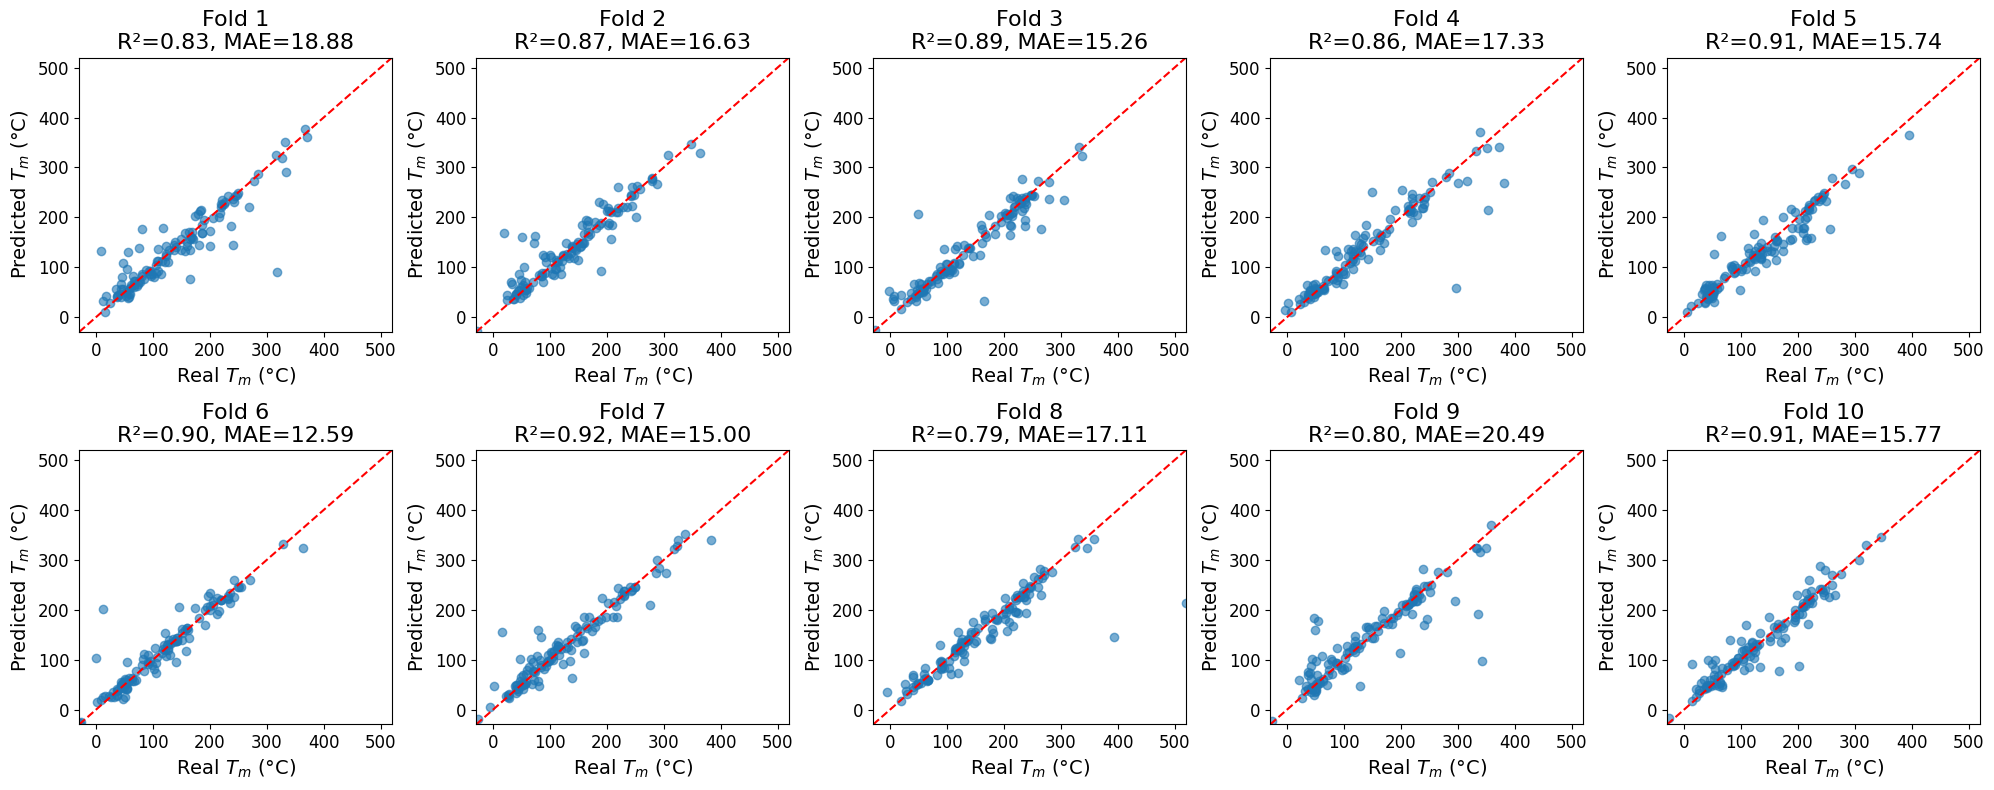

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib
import os
import matplotlib.pyplot as plt 


X_Tm_real = data_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_real = data_Tm_clean['Tm'].tolist()
X = np.array(X_Tm_real)
y = np.array(y_Tm_real)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []


test_true_list = []
test_pred_list = []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,           
        random_state=42
    )

   
    model =  XGBRegressor(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist' 
    )
    
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))


    test_true_list.append(y_test)
    test_pred_list.append(test_preds)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()


all_true = np.concatenate(test_true_list)
all_pred = np.concatenate(test_pred_list)
min_val = min(all_true.min(), all_pred.min())
max_val = max(all_true.max(), all_pred.max())

for i in range(10):
    ax = axes[i]
    ax.scatter(test_true_list[i], test_pred_list[i], alpha=0.6)


    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=1.5
    )
    
    r2 = r2_test_scores[i]
    mae = mae_test_scores[i]
    ax.set_title(f'Fold {i+1}\nR²={r2:.2f}, MAE={mae:.2f}', fontsize=16)


    ax.set_xlabel('Real $T_{m}$ (°C)', fontsize=14)
    ax.set_ylabel('Predicted $T_{m}$ (°C)', fontsize=14)
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('251211_real_Tm_10_cv.jpg', dpi=400)



#### 3.1.3 SVM

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


X = np.array(X_Tm_real)
y = np.array(y_Tm_real)

param_grid = {
    'C': [1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2],
    'gamma': [0.01, 0.05, 0.1]
}

param_combinations = list(product(
    param_grid['C'],
    param_grid['epsilon'],
    param_grid['gamma']
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2 = -np.inf
best_results_svm = {}

for C, eps, gamma in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=1/9, random_state=42
        )

        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                C=C,
                epsilon=eps,
                gamma=gamma,
                kernel='rbf'
            ))
        ])

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: C={C}, epsilon={eps}, gamma={gamma} "
        f"=> mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_results_svm = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'C': C,
                'epsilon': eps,
                'gamma': gamma,
                'kernel': 'rbf'
            }
        }

print("\n✅ Best Parameters and R2 Score (SVR):")
print(best_results_svm)


Params: C=1, epsilon=0.01, gamma=0.01 => mean R2: 0.0961
Params: C=1, epsilon=0.01, gamma=0.05 => mean R2: 0.0282
Params: C=1, epsilon=0.01, gamma=0.1 => mean R2: 0.0115
Params: C=1, epsilon=0.05, gamma=0.01 => mean R2: 0.0962
Params: C=1, epsilon=0.05, gamma=0.05 => mean R2: 0.0283
Params: C=1, epsilon=0.05, gamma=0.1 => mean R2: 0.0115
Params: C=1, epsilon=0.1, gamma=0.01 => mean R2: 0.0962
Params: C=1, epsilon=0.1, gamma=0.05 => mean R2: 0.0283
Params: C=1, epsilon=0.1, gamma=0.1 => mean R2: 0.0115
Params: C=1, epsilon=0.2, gamma=0.01 => mean R2: 0.0962
Params: C=1, epsilon=0.2, gamma=0.05 => mean R2: 0.0284
Params: C=1, epsilon=0.2, gamma=0.1 => mean R2: 0.0116
Params: C=10, epsilon=0.01, gamma=0.01 => mean R2: 0.3586
Params: C=10, epsilon=0.01, gamma=0.05 => mean R2: 0.2286
Params: C=10, epsilon=0.01, gamma=0.1 => mean R2: 0.1800
Params: C=10, epsilon=0.05, gamma=0.01 => mean R2: 0.3586
Params: C=10, epsilon=0.05, gamma=0.05 => mean R2: 0.2286
Params: C=10, epsilon=0.05, gamma=0.1

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = np.array(X_Tm_real)
y = np.array(y_Tm_real)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

    
    model =  Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                C=100,
                epsilon=0.2,
                gamma=0.01,
                kernel='rbf'
            ))
        ])
    
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

   
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [114]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 613.6610 ± 44.3876, MAE: 8.8500 ± 0.2720, R2: 0.9133 ± 0.0054
Mean Validation MSE: 2643.9169 ± 665.3927, MAE: 30.4737 ± 4.0258, R2: 0.6292 ± 0.0759
Mean Test MSE: 2760.6265 ± 716.2725, MAE: 30.7426 ± 3.2240, R2: 0.6102 ± 0.0644


#### 3.1.4 MLP

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


X = np.array(X_Tm_real)
y = np.array(y_Tm_real)

param_grid_mlp = {
    'hidden_layer_sizes': [(64, 64), (128, 64), (128, 128)],
    'alpha': [1e-4, 1e-3, 1e-2],            
    'learning_rate_init': [1e-3, 5e-3],     
}

param_combinations_mlp = list(product(
    param_grid_mlp['hidden_layer_sizes'],
    param_grid_mlp['alpha'],
    param_grid_mlp['learning_rate_init'],
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2_mlp = -np.inf
best_results_mlp = {}

for hls, alpha, lr_init in param_combinations_mlp:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=0.111, random_state=42
        )

        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=hls,
                alpha=alpha,
                learning_rate_init=lr_init,
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=42,
                early_stopping=True,      
                n_iter_no_change=20,
                verbose=False
            ))
        ])

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: hidden_layer_sizes={hls}, alpha={alpha}, "
        f"learning_rate_init={lr_init} => mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2_mlp:
        best_r2_mlp = mean_r2_valid
        best_results_mlp = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'hidden_layer_sizes': hls,
                'alpha': alpha,
                'learning_rate_init': lr_init,
                'activation': 'relu',
                'solver': 'adam',
            }
        }

print("\n✅ Best Parameters and R2 Score (MLP):")
print(best_results_mlp)


Params: hidden_layer_sizes=(64, 64), alpha=0.0001, learning_rate_init=0.001 => mean R2: 0.5672
Params: hidden_layer_sizes=(64, 64), alpha=0.0001, learning_rate_init=0.005 => mean R2: 0.5951
Params: hidden_layer_sizes=(64, 64), alpha=0.001, learning_rate_init=0.001 => mean R2: 0.5666
Params: hidden_layer_sizes=(64, 64), alpha=0.001, learning_rate_init=0.005 => mean R2: 0.5953
Params: hidden_layer_sizes=(64, 64), alpha=0.01, learning_rate_init=0.001 => mean R2: 0.5530
Params: hidden_layer_sizes=(64, 64), alpha=0.01, learning_rate_init=0.005 => mean R2: 0.6021
Params: hidden_layer_sizes=(128, 64), alpha=0.0001, learning_rate_init=0.001 => mean R2: 0.5268
Params: hidden_layer_sizes=(128, 64), alpha=0.0001, learning_rate_init=0.005 => mean R2: 0.4878
Params: hidden_layer_sizes=(128, 64), alpha=0.001, learning_rate_init=0.001 => mean R2: 0.5234
Params: hidden_layer_sizes=(128, 64), alpha=0.001, learning_rate_init=0.005 => mean R2: 0.4972
Params: hidden_layer_sizes=(128, 64), alpha=0.01, lear

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os

X_Tm_real = data_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_real = data_Tm_clean['Tm'].tolist()
X = np.array(X_Tm_real)
y = np.array(y_Tm_real)

kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

   
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

   
    model =  Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=(64, 64),
                alpha=0.01,
                learning_rate_init=0.005,
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=42,
                early_stopping=True,       
                n_iter_no_change=20,
                verbose=False
            ))
        ])
    
    model.fit(X_train, y_train)

   
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [20]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 577.9253 ± 109.3702, MAE: 13.1301 ± 1.6757, R2: 0.9183 ± 0.0155
Mean Validation MSE: 2784.1664 ± 2345.9091, MAE: 24.0974 ± 4.7724, R2: 0.6021 ± 0.3428
Mean Test MSE: 18408.8515 ± 31948.5982, MAE: 29.9663 ± 10.8593, R2: -1.6438 ± 4.5826


### 3.2 LLM $T_m$ Prediction performance

#### 3.2.1 RF

In [105]:
### find best RF param
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_Tm_gpt = data_gpt_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_gpt = data_gpt_Tm_clean['Melting temperature'].tolist()

X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)

best_r2 = -np.inf
best_params = None
best_results = {}

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3]
}


from itertools import product
param_combinations = list(product(param_grid['n_estimators'], param_grid['max_depth'],
                                   param_grid['min_samples_split'], param_grid['min_samples_leaf']))
kf = KFold(n_splits=10, shuffle=True, random_state=30)

for n_est, max_d, min_split, min_leaf in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_full, X_test = X[train_idx], X[test_idx]
        y_train_full, y_test = y[train_idx], y[test_idx]
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_full, y_train_full,
            test_size=1/9,          
            random_state=42
        )
        
        model = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)
        
        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)
    
    mean_r2_valid = np.mean(r2_valid_scores)
    print(f"Params: n_estimators={n_est}, max_depth={max_d}, min_samples_split={min_split}, min_samples_leaf={min_leaf} => mean R2: {mean_r2_valid:.4f}")
    
    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_params = (n_est, max_d, min_split, min_leaf)
        best_results = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'n_estimators': n_est,
                'max_depth': max_d,
                'min_samples_split': min_split,
                'min_samples_leaf': min_leaf
            }
        }

print("\n✅ Best Parameters and R2 Score:")
print(best_results)


Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1 => mean R2: 0.7902
Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=2 => mean R2: 0.7761
Params: n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=3 => mean R2: 0.7619
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=1 => mean R2: 0.7903
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=2 => mean R2: 0.7761
Params: n_estimators=100, max_depth=None, min_samples_split=3, min_samples_leaf=3 => mean R2: 0.7619
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=1 => mean R2: 0.7901
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=2 => mean R2: 0.7761
Params: n_estimators=100, max_depth=None, min_samples_split=4, min_samples_leaf=3 => mean R2: 0.7619
Params: n_estimators=100, max_depth=10, min_samples_split=2, min_samples_leaf=1 => mean R2:

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_Tm_gpt = data_gpt_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_gpt = data_gpt_Tm_clean['Melting temperature'].tolist()

X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

   
    model = RandomForestRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_split=3,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [34]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 190.3104 ± 11.4859, MAE: 8.3348 ± 0.2507, R2: 0.9742 ± 0.0018
Mean Validation MSE: 1439.2613 ± 438.5786, MAE: 20.9424 ± 2.7169, R2: 0.7953 ± 0.0646
Mean Test MSE: 1219.8766 ± 530.0422, MAE: 20.2700 ± 3.1304, R2: 0.8259 ± 0.0923


#### 3.2.2 Xgboost

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)

param_grid = {
    'n_estimators': [100,150,200],        
    'max_depth': [None, 10, 20],            
    'learning_rate': [0.05, 0.1],      
    'subsample': [0.8, 1.0],           
    'colsample_bytree': [0.8, 1.0]      
}

param_combinations = list(product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['subsample'],
    param_grid['colsample_bytree']
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2 = -np.inf
best_results = {}

for (n_est, max_d, lr, subsample, colsample) in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=1/9, random_state=42
        )

        model = XGBRegressor(
            n_estimators=n_est,
            max_depth=max_d,
            learning_rate=lr,
            subsample=subsample,
            colsample_bytree=colsample,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            tree_method='hist'  
        )

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: n_estimators={n_est}, max_depth={max_d}, "
        f"learning_rate={lr}, subsample={subsample}, "
        f"colsample_bytree={colsample} "
        f"=> mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_results = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'n_estimators': n_est,
                'max_depth': max_d,
                'learning_rate': lr,
                'subsample': subsample,
                'colsample_bytree': colsample
            }
        }

print("\n✅ Best Parameters and R2 Score (XGBoost):")
print(best_results)

Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8 => mean R2: 0.8087
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=0.8, colsample_bytree=1.0 => mean R2: 0.8071
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=1.0, colsample_bytree=0.8 => mean R2: 0.8044
Params: n_estimators=100, max_depth=None, learning_rate=0.05, subsample=1.0, colsample_bytree=1.0 => mean R2: 0.8005
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8 => mean R2: 0.8269
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=0.8, colsample_bytree=1.0 => mean R2: 0.8276
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0, colsample_bytree=0.8 => mean R2: 0.8191
Params: n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0, colsample_bytree=1.0 => mean R2: 0.8154
Params: n_estimators=100, max_depth=10, learning_rate=0.05, subsampl

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
from xgboost import XGBRegressor

if not os.path.exists('251122_LLM_Tm_XGBoost_10fold_saved_models'):
    os.makedirs('251122_LLM_Tm_XGBoost_10fold_saved_models')

X_Tm_gpt = data_gpt_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_gpt = data_gpt_Tm_clean['Melting temperature'].tolist()
X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

    
    model =  XGBRegressor(
        n_estimators=200,
        max_depth=None,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=1.0,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'  
    )
    
    model.fit(X_train, y_train)

    model_filename = f'251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_{i+1:03d}.pkl'
    joblib.dump(model, model_filename)
    print(f'Model saved as {model_filename}')

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_001.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_002.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_003.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_004.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_005.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_006.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_007.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_008.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_009.pkl
Model saved as 251122_LLM_Tm_XGBoost_10fold_saved_models/XGB_010.pkl


In [36]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 55.9849 ± 3.4355, MAE: 5.4215 ± 0.1842, R2: 0.9924 ± 0.0005
Mean Validation MSE: 1121.4581 ± 340.0684, MAE: 19.0104 ± 2.6695, R2: 0.8379 ± 0.0575
Mean Test MSE: 1092.9769 ± 484.4866, MAE: 18.7769 ± 3.3177, R2: 0.8452 ± 0.0800


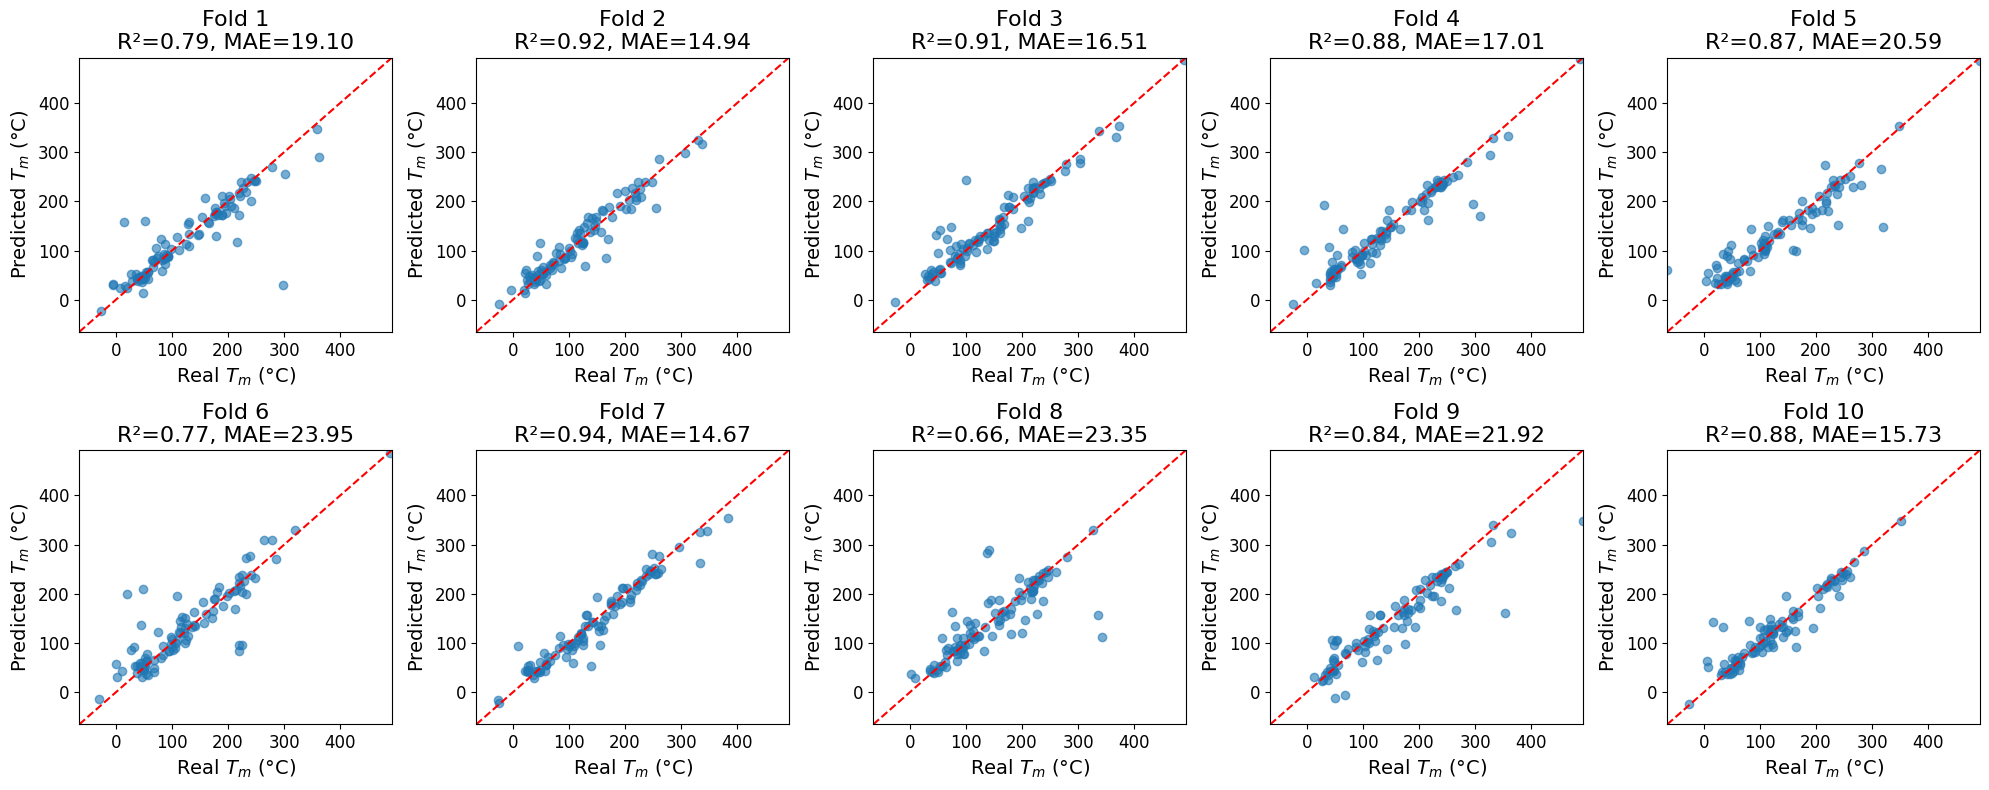

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
from xgboost import XGBRegressor
import matplotlib.pyplot as plt   


X_Tm_gpt = data_gpt_Tm_clean['morgan_fp_with_freq'].tolist()
y_Tm_gpt = data_gpt_Tm_clean['Melting temperature'].tolist()
X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []


test_true_list = []
test_pred_list = []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

  
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

   
    model =  XGBRegressor(
        n_estimators=200,
        max_depth=None,           
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=1.0,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'        
    )
    
    model.fit(X_train, y_train)

    
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))

    
    test_true_list.append(y_test)
    test_pred_list.append(test_preds)


fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()


all_true = np.concatenate(test_true_list)
all_pred = np.concatenate(test_pred_list)
min_val = min(all_true.min(), all_pred.min())
max_val = max(all_true.max(), all_pred.max())

for i in range(10):
    ax = axes[i]
    ax.scatter(test_true_list[i], test_pred_list[i], alpha=0.6)

    
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=1.5
    )
    
    r2 = r2_test_scores[i]
    mae = mae_test_scores[i]
    ax.set_title(f'Fold {i+1}\nR²={r2:.2f}, MAE={mae:.2f}', fontsize=16)

   
    ax.set_xlabel('Real $T_{m}$ (°C)', fontsize=14)
    ax.set_ylabel('Predicted $T_{m}$ (°C)', fontsize=14)
    
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.savefig('251211_LLM__Tm_10_cv.jpg', dpi=400)



#### 3.2.3 SVM

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)

param_grid = {
    'C': [1, 10, 50, 100],
    'epsilon': [0.01, 0.05, 0.1, 0.2],
    'gamma': [0.01, 0.05, 0.1]
}

param_combinations = list(product(
    param_grid['C'],
    param_grid['epsilon'],
    param_grid['gamma']
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2 = -np.inf
best_results_svm = {}

for C, eps, gamma in param_combinations:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=1/9, random_state=42
        )

        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                C=C,
                epsilon=eps,
                gamma=gamma,
                kernel='rbf'
            ))
        ])

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: C={C}, epsilon={eps}, gamma={gamma} "
        f"=> mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2:
        best_r2 = mean_r2_valid
        best_results_svm = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'C': C,
                'epsilon': eps,
                'gamma': gamma,
                'kernel': 'rbf'
            }
        }

print("\n✅ Best Parameters and R2 Score (SVR):")
print(best_results_svm)


Params: C=1, epsilon=0.01, gamma=0.01 => mean R2: 0.0760
Params: C=1, epsilon=0.01, gamma=0.05 => mean R2: 0.0306
Params: C=1, epsilon=0.01, gamma=0.1 => mean R2: 0.0175
Params: C=1, epsilon=0.05, gamma=0.01 => mean R2: 0.0760
Params: C=1, epsilon=0.05, gamma=0.05 => mean R2: 0.0307
Params: C=1, epsilon=0.05, gamma=0.1 => mean R2: 0.0175
Params: C=1, epsilon=0.1, gamma=0.01 => mean R2: 0.0760
Params: C=1, epsilon=0.1, gamma=0.05 => mean R2: 0.0307
Params: C=1, epsilon=0.1, gamma=0.1 => mean R2: 0.0175
Params: C=1, epsilon=0.2, gamma=0.01 => mean R2: 0.0760
Params: C=1, epsilon=0.2, gamma=0.05 => mean R2: 0.0307
Params: C=1, epsilon=0.2, gamma=0.1 => mean R2: 0.0175
Params: C=10, epsilon=0.01, gamma=0.01 => mean R2: 0.2948
Params: C=10, epsilon=0.01, gamma=0.05 => mean R2: 0.1931
Params: C=10, epsilon=0.01, gamma=0.1 => mean R2: 0.1512
Params: C=10, epsilon=0.05, gamma=0.01 => mean R2: 0.2948
Params: C=10, epsilon=0.05, gamma=0.05 => mean R2: 0.1931
Params: C=10, epsilon=0.05, gamma=0.1

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
   
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

   
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,           
        random_state=42
    )


    model =  Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(
                C=100,
                epsilon=0.01,
                gamma=0.01,
                kernel='rbf'
            ))
        ])
    
    model.fit(X_train, y_train)

  
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

   
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [23]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 691.1546 ± 59.8694, MAE: 9.3160 ± 0.4302, R2: 0.9063 ± 0.0084
Mean Validation MSE: 3050.0544 ± 566.9890, MAE: 33.6406 ± 3.0444, R2: 0.5707 ± 0.0573
Mean Test MSE: 3221.4752 ± 656.2643, MAE: 33.6947 ± 3.8992, R2: 0.5557 ± 0.0507


#### 3.2.4 MLP

In [ ]:
import numpy as np
from itertools import product
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)

param_grid_mlp = {
    'hidden_layer_sizes': [(64, 64), (128, 64), (128, 128)],
    'alpha': [1e-4, 1e-3, 1e-2],           
    'learning_rate_init': [1e-3, 5e-3],     
}

param_combinations_mlp = list(product(
    param_grid_mlp['hidden_layer_sizes'],
    param_grid_mlp['alpha'],
    param_grid_mlp['learning_rate_init'],
))

kf = KFold(n_splits=10, shuffle=True, random_state=30)

best_r2_mlp = -np.inf
best_results_mlp = {}

for hls, alpha, lr_init in param_combinations_mlp:
    r2_valid_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train_all, X_test = X[train_idx], X[test_idx]
        y_train_all, y_test = y[train_idx], y[test_idx]

        
        X_train, X_valid, y_train, y_valid = train_test_split(
            X_train_all, y_train_all, test_size=0.111, random_state=42
        )

        
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=hls,
                alpha=alpha,
                learning_rate_init=lr_init,
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=42,
                early_stopping=True,       
                n_iter_no_change=20,
                verbose=False
            ))
        ])

        model.fit(X_train, y_train)
        valid_preds = model.predict(X_valid)

        r2_valid = r2_score(y_valid, valid_preds)
        r2_valid_scores.append(r2_valid)

    mean_r2_valid = np.mean(r2_valid_scores)
    print(
        f"Params: hidden_layer_sizes={hls}, alpha={alpha}, "
        f"learning_rate_init={lr_init} => mean R2: {mean_r2_valid:.4f}"
    )

    if mean_r2_valid > best_r2_mlp:
        best_r2_mlp = mean_r2_valid
        best_results_mlp = {
            'mean_r2_valid': mean_r2_valid,
            'params': {
                'hidden_layer_sizes': hls,
                'alpha': alpha,
                'learning_rate_init': lr_init,
                'activation': 'relu',
                'solver': 'adam',
            }
        }

print("\n✅ Best Parameters and R2 Score (MLP):")
print(best_results_mlp)


Params: hidden_layer_sizes=(64, 64), alpha=0.0001, learning_rate_init=0.001 => mean R2: 0.5094
Params: hidden_layer_sizes=(64, 64), alpha=0.0001, learning_rate_init=0.005 => mean R2: 0.3120
Params: hidden_layer_sizes=(64, 64), alpha=0.001, learning_rate_init=0.001 => mean R2: 0.5086
Params: hidden_layer_sizes=(64, 64), alpha=0.001, learning_rate_init=0.005 => mean R2: 0.3213
Params: hidden_layer_sizes=(64, 64), alpha=0.01, learning_rate_init=0.001 => mean R2: 0.5086
Params: hidden_layer_sizes=(64, 64), alpha=0.01, learning_rate_init=0.005 => mean R2: 0.2971
Params: hidden_layer_sizes=(128, 64), alpha=0.0001, learning_rate_init=0.001 => mean R2: 0.5226
Params: hidden_layer_sizes=(128, 64), alpha=0.0001, learning_rate_init=0.005 => mean R2: 0.4488
Params: hidden_layer_sizes=(128, 64), alpha=0.001, learning_rate_init=0.001 => mean R2: 0.5221
Params: hidden_layer_sizes=(128, 64), alpha=0.001, learning_rate_init=0.005 => mean R2: 0.4490
Params: hidden_layer_sizes=(128, 64), alpha=0.01, lear

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import os
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = np.array(X_Tm_gpt)
y = np.array(y_Tm_gpt)


kf = KFold(n_splits=10, shuffle=True, random_state=30)

mse_train_scores, mse_valid_scores, mse_test_scores = [], [], []
mae_train_scores, mae_valid_scores, mae_test_scores = [], [], []
r2_train_scores,  r2_valid_scores,  r2_test_scores  = [], [], []

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    
    X_train_full, X_test = X[train_idx], X[test_idx]
    y_train_full, y_test = y[train_idx], y[test_idx]

    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full, y_train_full,
        test_size=1/9,            
        random_state=42
    )

    
    model =  Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=(128, 64),
                alpha=0.0001,
                learning_rate_init=0.001,
                activation='relu',
                solver='adam',
                max_iter=200,
                random_state=42,
                early_stopping=True,       
                n_iter_no_change=20,
                verbose=False
            ))
        ])
    
    model.fit(X_train, y_train)

   
    train_preds = model.predict(X_train)
    valid_preds = model.predict(X_valid)
    test_preds  = model.predict(X_test)

    
    mse_train_scores.append(mean_squared_error(y_train, train_preds))
    mse_valid_scores.append(mean_squared_error(y_valid, valid_preds))
    mse_test_scores.append(mean_squared_error(y_test,  test_preds))

    mae_train_scores.append(mean_absolute_error(y_train, train_preds))
    mae_valid_scores.append(mean_absolute_error(y_valid, valid_preds))
    mae_test_scores.append(mean_absolute_error(y_test,  test_preds))

    r2_train_scores.append(r2_score(y_train, train_preds))
    r2_valid_scores.append(r2_score(y_valid, valid_preds))
    r2_test_scores.append(r2_score(y_test,  test_preds))



In [25]:
print(f"Mean Train MSE: {np.mean(mse_train_scores):.4f} ± {np.std(mse_train_scores):.4f}, MAE: {np.mean(mae_train_scores):.4f} ± {np.std(mae_train_scores):.4f}, R2: {np.mean(r2_train_scores):.4f} ± {np.std(r2_train_scores):.4f}")
print(f"Mean Validation MSE: {np.mean(mse_valid_scores):.4f} ± {np.std(mse_valid_scores):.4f}, MAE: {np.mean(mae_valid_scores):.4f} ± {np.std(mae_valid_scores):.4f}, R2: {np.mean(r2_valid_scores):.4f} ± {np.std(r2_valid_scores):.4f}")
print(f"Mean Test MSE: {np.mean(mse_test_scores):.4f} ± {np.std(mse_test_scores):.4f}, MAE: {np.mean(mae_test_scores):.4f} ± {np.std(mae_test_scores):.4f}, R2: {np.mean(r2_test_scores):.4f} ± {np.std(r2_test_scores):.4f}")

Mean Train MSE: 725.8411 ± 176.5046, MAE: 14.9574 ± 1.9642, R2: 0.9019 ± 0.0225
Mean Validation MSE: 3456.6716 ± 2842.7964, MAE: 28.4707 ± 4.0817, R2: 0.5226 ± 0.3716
Mean Test MSE: 4610.7573 ± 3328.1385, MAE: 29.7633 ± 6.3460, R2: 0.3699 ± 0.4228
